In [1]:
DATADIR = "/Users/katst103/Documents/GitHub/comparativeCD/05_network/" 

✅ Difference volcano saved: GO_difference_volcano.pdf


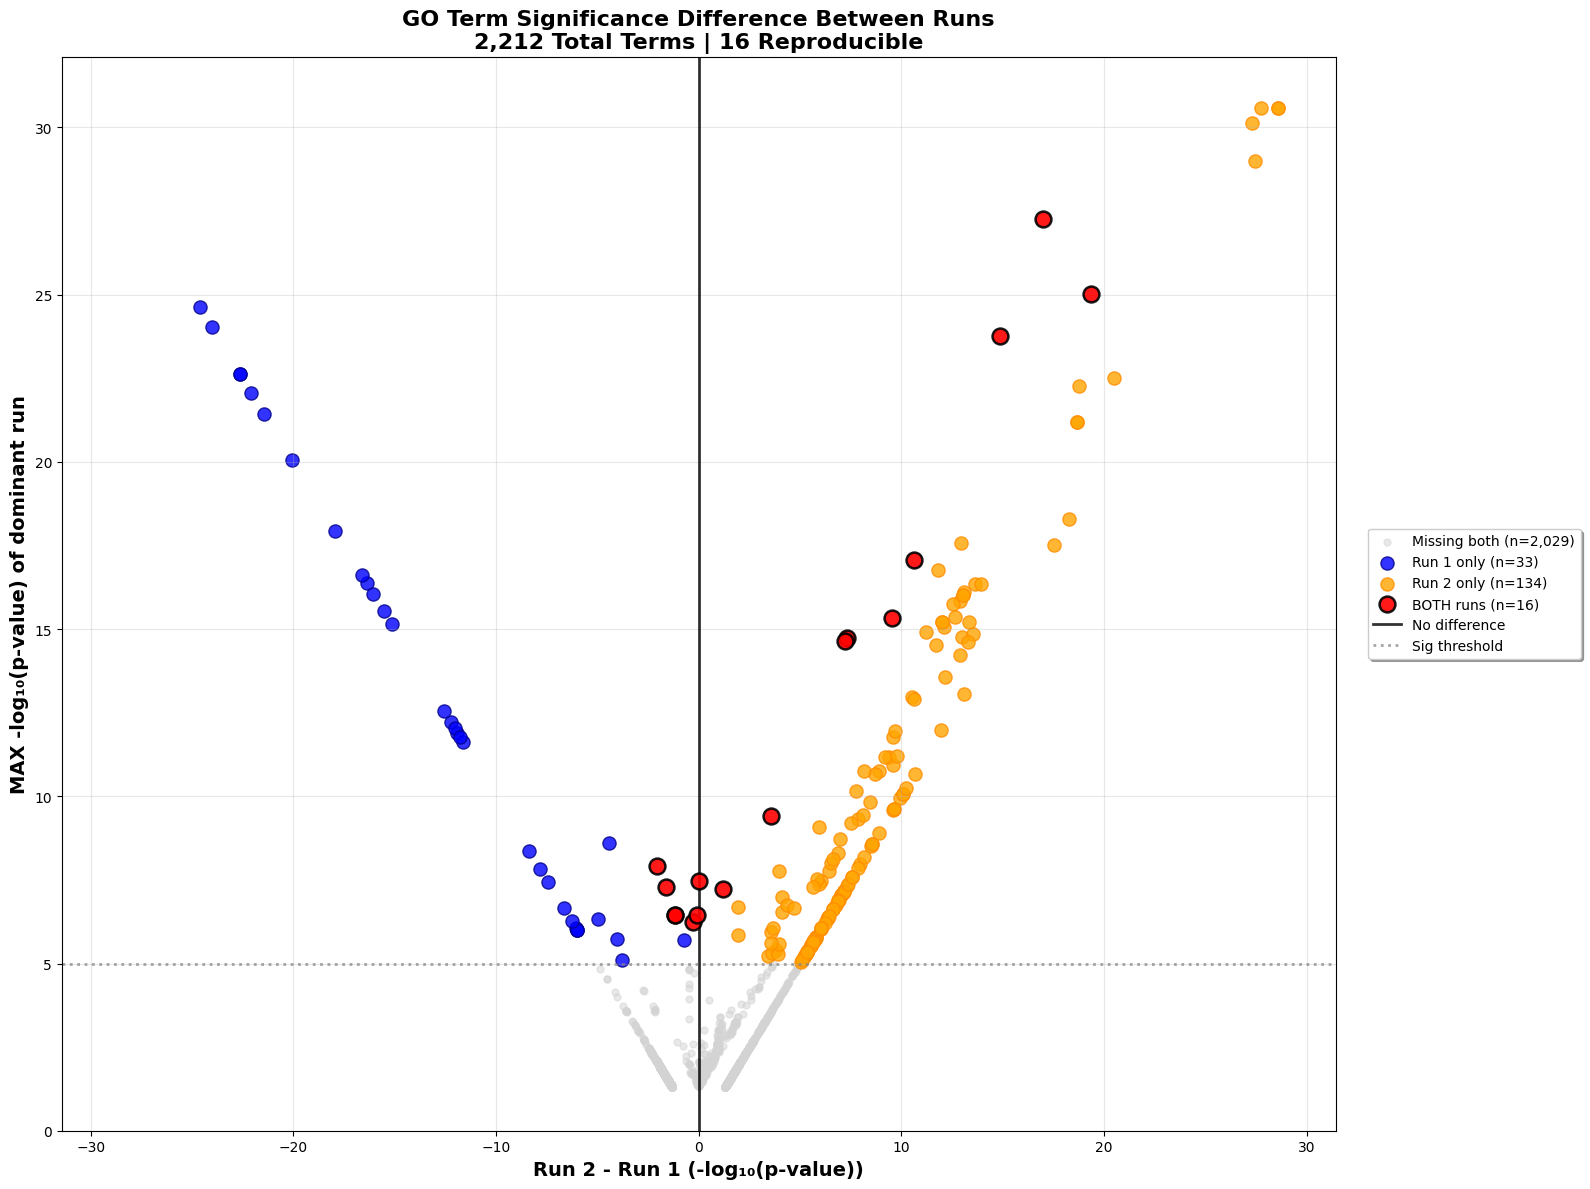


📊 TOP 10 BY Run 2 - Run 1 DIFFERENCE:
run                                            run1    run2    diff   y_max
name                                                                       
anterograde trans-synaptic signaling          2.024  30.591  28.567  30.591
chemical synaptic transmission                2.024  30.591  28.567  30.591
trans-synaptic signaling                      2.862  30.591  27.729  30.591
regulation of membrane potential              1.548  28.985  27.437  28.985
synaptic signaling                            2.813  30.121  27.308  30.121
cell-cell signaling                           2.024  22.508  20.484  22.508
nervous system development                    5.667  25.019  19.352  25.019
regulation of biological quality              3.503  22.267  18.764  22.267
modulation of chemical synaptic transmission  2.505  21.180  18.675  21.180
regulation of trans-synaptic signaling        2.505  21.180  18.675  21.180

📊 TOP 10 BY Run 1 - Run 2 DIFFERENCE:
run       

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# LOAD DATA 
# =============================================================================
df1 = pd.read_csv(DATADIR+"data/OCD_ONLY_hierachy_full_GO_enrichment.tsv",  sep="\t", index_col=0)
df2 = pd.read_csv(DATADIR+"data/Compulsive_hierachy_full_GO_enrichment_251023.tsv",  sep="\t", index_col=0)
df1['run'] = 'run1'
df2['run'] = 'run2'
df = pd.concat([df1, df2], ignore_index=True)
term_col = 'name'

df['neg_log10_p'] = -np.log10(df['p_value'])
df_sig = df[df['significant'] == True]
max_pivot = df_sig.groupby([term_col, 'run'])['neg_log10_p'].max().reset_index()

pivot_table = max_pivot.pivot(index=term_col, columns='run', values='neg_log10_p').fillna(0)
scatter_df = pivot_table

# Difference metrics
scatter_df['diff'] = scatter_df['run2'] - scatter_df['run1']
scatter_df['y_max'] = np.maximum(scatter_df['run1'], scatter_df['run2'])

# **COLOR CODING SAME AS MAIN PLOT**
scatter_df['in_both'] = (scatter_df['run1'] > 5) & (scatter_df['run2'] > 5)
scatter_df['run1_only'] = (scatter_df['run1'] > 5) & (scatter_df['run2'] <= 5)
scatter_df['run2_only'] = (scatter_df['run1'] <= 5) & (scatter_df['run2'] > 5)
scatter_df['neither'] = (scatter_df['run1'] <= 5) & (scatter_df['run2'] <= 5)

x_vals = scatter_df['diff']
y_vals = scatter_df['y_max']

# =============================================================================
# SAVE FULL TABLE TO TXT
# =============================================================================

full_table = scatter_df.reset_index().rename(columns={term_col: "term"})
full_table = full_table[
    ["term", "run1", "run2", "diff", "y_max", "in_both", "run1_only", "run2_only", "neither"]
].sort_values("diff", ascending=False)

full_table.to_csv(DATADIR+"plotting/CCD-OCD_OCD_GO_difference_volcano_all_terms.txt", sep="\t", index=False)



# =============================================================================
# DIFFERENCE PLOT WITH ORIGINAL COLOR SCHEME
# =============================================================================
plt.figure(figsize=(16, 12))

# 1. GRAY - neither run significant
mask_neither = scatter_df['neither']
plt.scatter(x_vals[mask_neither], y_vals[mask_neither], 
           c='lightgray', s=25, alpha=0.5, label=f'Missing both (n={mask_neither.sum():,})')

# 2. BLUE - Run 1 only (left side bias)
mask_r1_only = scatter_df['run1_only']
plt.scatter(x_vals[mask_r1_only], y_vals[mask_r1_only], 
           c='blue', s=90, alpha=0.8, edgecolors='darkblue', linewidth=1,
           label=f'Run 1 only (n={mask_r1_only.sum():,})')

# 3. ORANGE - Run 2 only (right side bias)
mask_r2_only = scatter_df['run2_only']
plt.scatter(x_vals[mask_r2_only], y_vals[mask_r2_only], 
           c='orange', s=90, alpha=0.8, edgecolors='darkorange', linewidth=1,
           label=f'Run 2 only (n={mask_r2_only.sum():,})')

# 4. RED - BOTH runs (center bias)
mask_both = scatter_df['in_both']
plt.scatter(x_vals[mask_both], y_vals[mask_both], 
           c='red', s=130, alpha=0.9, edgecolors='black', linewidth=1.8,
           label=f'BOTH runs (n={mask_both.sum():,})', zorder=10)

# Reference lines
plt.axvline(x=0, color='black', linestyle='-', lw=2, alpha=0.8, label='No difference')
plt.axhline(y=5, color='gray', linestyle=':', alpha=0.7, lw=2, label='Sig threshold')

plt.xlabel('Run 2 - Run 1 (-log₁₀(p-value))', fontsize=14, fontweight='bold')
plt.ylabel('MAX -log₁₀(p-value) of dominant run', fontsize=14, fontweight='bold')
plt.title('GO Term Significance Difference Between Runs\n'
          f'{len(scatter_df):,} Total Terms | {scatter_df["in_both"].sum():,} Reproducible', 
          fontsize=16, fontweight='bold')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3)

# Symmetric x-axis
max_diff = max(abs(x_vals.max()), abs(x_vals.min()))
plt.xlim(-max_diff*1.1, max_diff*1.1)
plt.ylim(0, y_vals.max()*1.05)

plt.tight_layout()
plt.savefig(DATADIR+'/plotting/GO_enrichment_CCDOCD_OCD_volcano_color.pdf', format='pdf', bbox_inches='tight', dpi=300)
print("✅ Difference volcano saved: GO_difference_volcano.pdf")
plt.show()

# TOP TERMS BY DIFFERENCE
print("\n📊 TOP 10 BY Run 2 - Run 1 DIFFERENCE:")
print(scatter_df.nlargest(10, 'diff')[['run1', 'run2', 'diff', 'y_max']].round(3))
print("\n📊 TOP 10 BY Run 1 - Run 2 DIFFERENCE:")
print(scatter_df.nsmallest(10, 'diff')[['run1', 'run2', 'diff', 'y_max']].round(3))


✅ Difference volcano saved: GO_difference_volcano.pdf


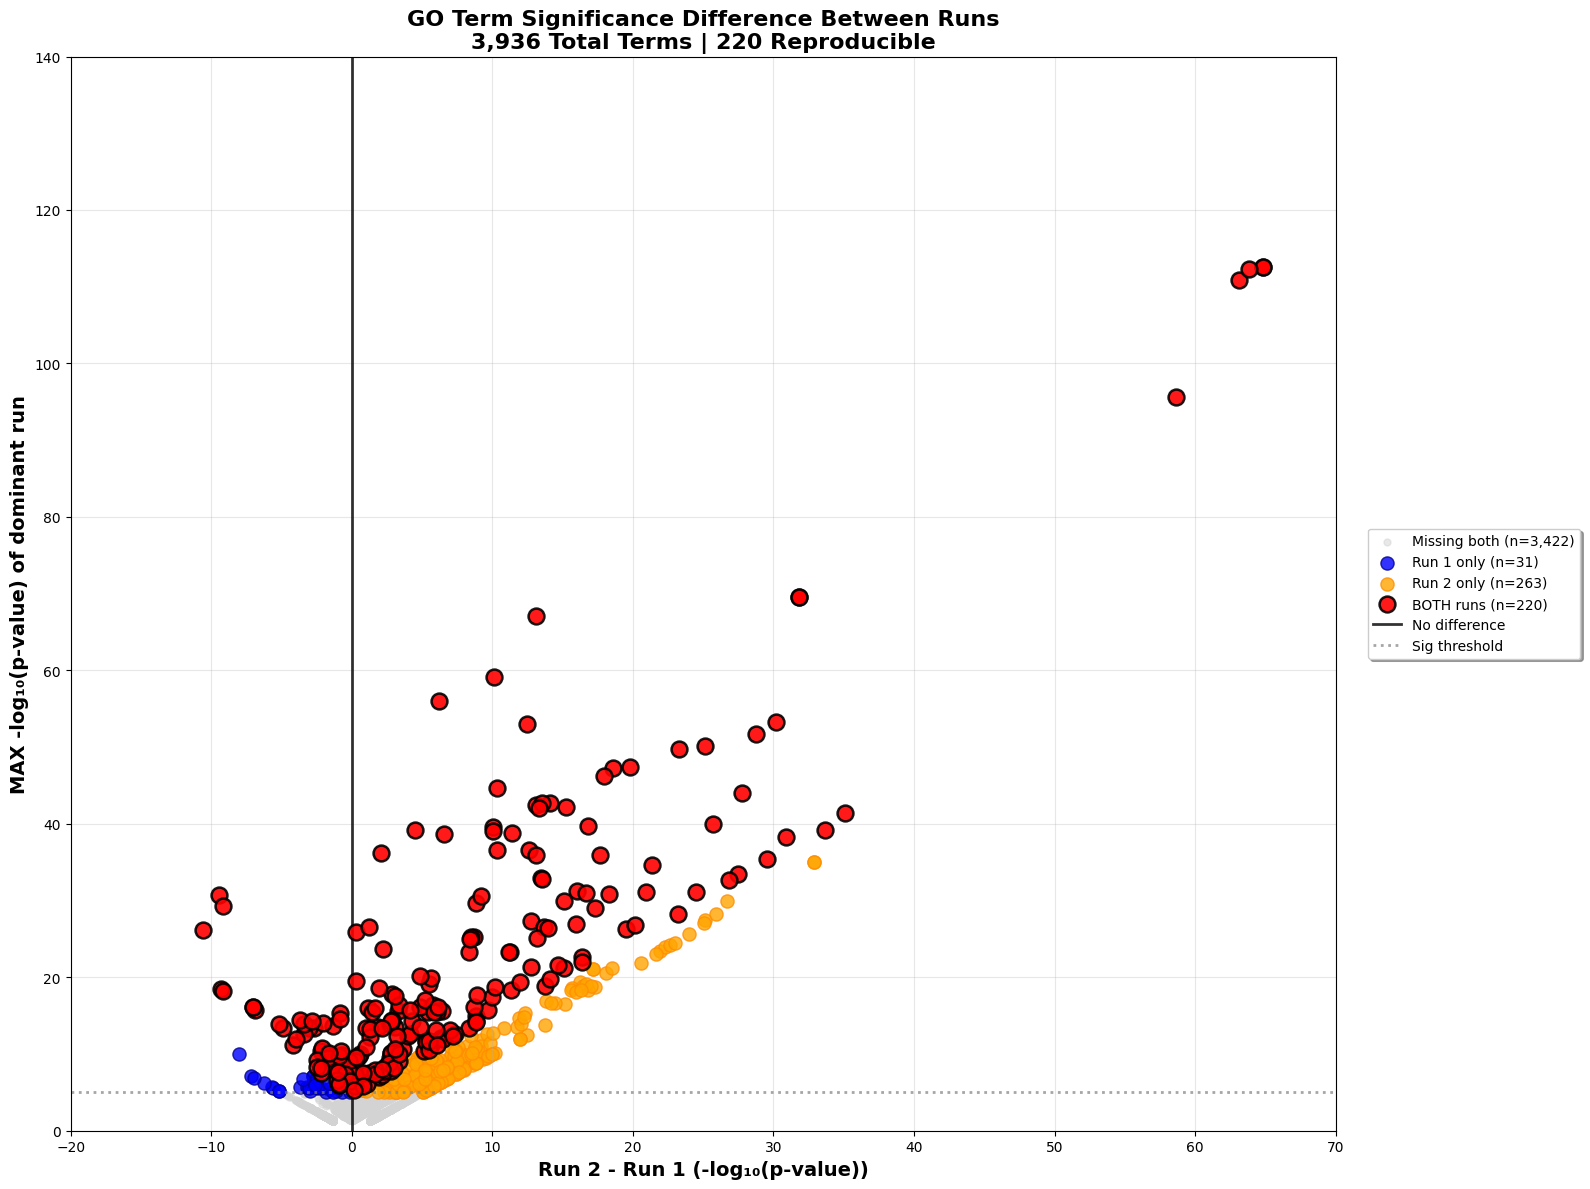


📊 TOP 10 BY Run 2 - Run 1 DIFFERENCE:
run                                             run1     run2    diff    y_max
name                                                                          
anterograde trans-synaptic signaling          47.736  112.547  64.810  112.547
chemical synaptic transmission                47.736  112.547  64.810  112.547
trans-synaptic signaling                      48.488  112.340  63.853  112.340
synaptic signaling                            47.736  110.845  63.108  110.845
cell-cell signaling                           37.003   95.646  58.643   95.646
monoatomic ion transmembrane transport         6.361   41.420  35.058   41.420
monoatomic ion transport                       5.557   39.194  33.637   39.194
proteoglycan biosynthetic process              2.096   35.008  32.912   35.008
proteoglycan metabolic process                 2.096   35.008  32.912   35.008
modulation of chemical synaptic transmission  37.773   69.588  31.815   69.588

📊 TOP 10 BY 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# LOAD DATA (same as before)
# =============================================================================
df1 = pd.read_csv(DATADIR+"data/DEP_ONLY_hierarchy_full_GO_enrichment.tsv",  sep="\t", index_col=0)
df2 = pd.read_csv(DATADIR+"data/DEP_CCD_hierachy_full_GO_enrichment.tsv",  sep="\t", index_col=0)
df1['run'] = 'run1'
df2['run'] = 'run2'
df = pd.concat([df1, df2], ignore_index=True)
term_col = 'name'

df['neg_log10_p'] = -np.log10(df['p_value'])
df_sig = df[df['significant'] == True]
max_pivot = df_sig.groupby([term_col, 'run'])['neg_log10_p'].max().reset_index()

pivot_table = max_pivot.pivot(index=term_col, columns='run', values='neg_log10_p').fillna(0)
scatter_df = pivot_table

# Difference metrics
scatter_df['diff'] = scatter_df['run2'] - scatter_df['run1']
scatter_df['y_max'] = np.maximum(scatter_df['run1'], scatter_df['run2'])

# **COLOR CODING SAME AS MAIN PLOT**
scatter_df['in_both'] = (scatter_df['run1'] > 5) & (scatter_df['run2'] > 5)
scatter_df['run1_only'] = (scatter_df['run1'] > 5) & (scatter_df['run2'] <= 5)
scatter_df['run2_only'] = (scatter_df['run1'] <= 5) & (scatter_df['run2'] > 5)
scatter_df['neither'] = (scatter_df['run1'] <= 5) & (scatter_df['run2'] <= 5)

x_vals = scatter_df['diff']
y_vals = scatter_df['y_max']

# =============================================================================
# SAVE FULL TABLE TO TXT
# =============================================================================

full_table = scatter_df.reset_index().rename(columns={term_col: "term"})
full_table = full_table[
    ["term", "run1", "run2", "diff", "y_max", "in_both", "run1_only", "run2_only", "neither"]
].sort_values("diff", ascending=False)

full_table.to_csv(DATADIR+"plotting/CCD-DEP_DEP_GO_difference_volcano_all_terms.txt", sep="\t", index=False)


# =============================================================================
# DIFFERENCE PLOT WITH ORIGINAL COLOR SCHEME
# =============================================================================
plt.figure(figsize=(16, 12))

# 1. GRAY - neither run significant
mask_neither = scatter_df['neither']
plt.scatter(x_vals[mask_neither], y_vals[mask_neither], 
           c='lightgray', s=25, alpha=0.5, label=f'Missing both (n={mask_neither.sum():,})')

# 2. BLUE - Run 1 only (left side bias)
mask_r1_only = scatter_df['run1_only']
plt.scatter(x_vals[mask_r1_only], y_vals[mask_r1_only], 
           c='blue', s=90, alpha=0.8, edgecolors='darkblue', linewidth=1,
           label=f'Run 1 only (n={mask_r1_only.sum():,})')

# 3. ORANGE - Run 2 only (right side bias)
mask_r2_only = scatter_df['run2_only']
plt.scatter(x_vals[mask_r2_only], y_vals[mask_r2_only], 
           c='orange', s=90, alpha=0.8, edgecolors='darkorange', linewidth=1,
           label=f'Run 2 only (n={mask_r2_only.sum():,})')

# 4. RED - BOTH runs (center bias)
mask_both = scatter_df['in_both']
plt.scatter(x_vals[mask_both], y_vals[mask_both], 
           c='red', s=130, alpha=0.9, edgecolors='black', linewidth=1.8,
           label=f'BOTH runs (n={mask_both.sum():,})', zorder=10)

# Reference lines
plt.axvline(x=0, color='black', linestyle='-', lw=2, alpha=0.8, label='No difference')
plt.axhline(y=5, color='gray', linestyle=':', alpha=0.7, lw=2, label='Sig threshold')

plt.xlabel('Run 2 - Run 1 (-log₁₀(p-value))', fontsize=14, fontweight='bold')
plt.ylabel('MAX -log₁₀(p-value) of dominant run', fontsize=14, fontweight='bold')
plt.title('GO Term Significance Difference Between Runs\n'
          f'{len(scatter_df):,} Total Terms | {scatter_df["in_both"].sum():,} Reproducible', 
          fontsize=16, fontweight='bold')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3)

# Symmetric x-axis
max_diff = max(abs(x_vals.max()), abs(x_vals.min()))
plt.xlim(-20,70) #-max_diff*1.1, max_diff*1.1
plt.ylim(0, 140) #change to match schizophrenia - before: y_vals.max()*1.05

plt.tight_layout()
plt.savefig(DATADIR+'/plotting/GO_enrichment_CCDDEP-DEP_volcano_color.pdf', format='pdf', bbox_inches='tight', dpi=300)
print("✅ Difference volcano saved: GO_difference_volcano.pdf")
plt.show()

# TOP TERMS BY DIFFERENCE
print("\n📊 TOP 10 BY Run 2 - Run 1 DIFFERENCE:")
print(scatter_df.nlargest(10, 'diff')[['run1', 'run2', 'diff', 'y_max']].round(3))
print("\n📊 TOP 10 BY Run 1 - Run 2 DIFFERENCE:")
print(scatter_df.nsmallest(10, 'diff')[['run1', 'run2', 'diff', 'y_max']].round(3))


✅ Difference volcano saved: GO_difference_volcano.pdf


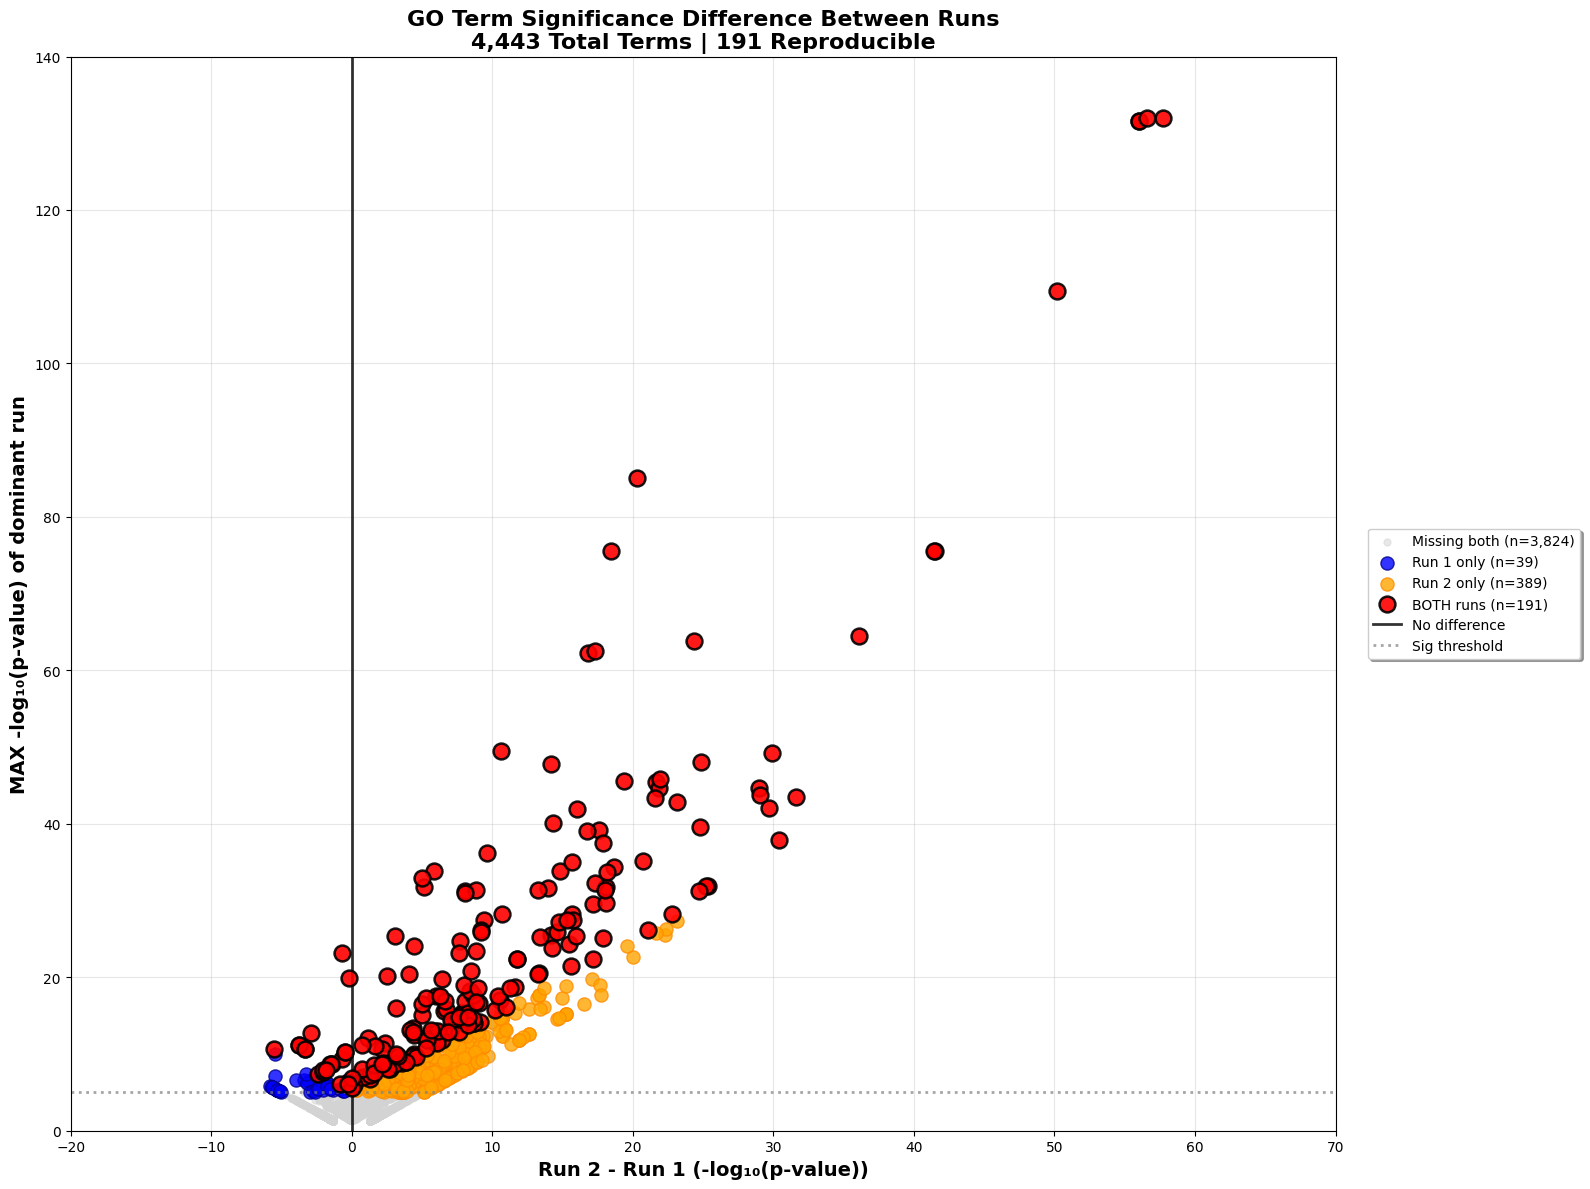


📊 TOP 10 BY Run 2 - Run 1 DIFFERENCE:
run                                             run1     run2    diff    y_max
name                                                                          
synaptic signaling                            74.289  131.989  57.700  131.989
trans-synaptic signaling                      75.415  131.989  56.574  131.989
anterograde trans-synaptic signaling          75.534  131.561  56.027  131.561
chemical synaptic transmission                75.534  131.561  56.027  131.561
cell-cell signaling                           59.299  109.457  50.158  109.457
modulation of chemical synaptic transmission  34.098   75.582  41.484   75.582
regulation of trans-synaptic signaling        34.094   75.544  41.450   75.544
nervous system development                    28.338   64.437  36.099   64.437
neuron development                            11.861   43.507  31.646   43.507
neuron projection development                  7.495   37.913  30.417   37.913

📊 TOP 10 BY 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# LOAD DATA (same as before)
# =============================================================================
df1 = pd.read_csv(DATADIR+"data/SCH_ONLY_hierachy_full_GO_enrichment.tsv",  sep="\t", index_col=0)
df2 = pd.read_csv(DATADIR+"data/SCH_CCD_hierachy_full_GO_enrichment.tsv",  sep="\t", index_col=0)
df1['run'] = 'run1'
df2['run'] = 'run2'
df = pd.concat([df1, df2], ignore_index=True)
term_col = 'name'

df['neg_log10_p'] = -np.log10(df['p_value'])
df_sig = df[df['significant'] == True]
max_pivot = df_sig.groupby([term_col, 'run'])['neg_log10_p'].max().reset_index()

pivot_table = max_pivot.pivot(index=term_col, columns='run', values='neg_log10_p').fillna(0)
scatter_df = pivot_table

# Difference metrics
scatter_df['diff'] = scatter_df['run2'] - scatter_df['run1']
scatter_df['y_max'] = np.maximum(scatter_df['run1'], scatter_df['run2'])

# **COLOR CODING SAME AS MAIN PLOT**
scatter_df['in_both'] = (scatter_df['run1'] > 5) & (scatter_df['run2'] > 5)
scatter_df['run1_only'] = (scatter_df['run1'] > 5) & (scatter_df['run2'] <= 5)
scatter_df['run2_only'] = (scatter_df['run1'] <= 5) & (scatter_df['run2'] > 5)
scatter_df['neither'] = (scatter_df['run1'] <= 5) & (scatter_df['run2'] <= 5)

x_vals = scatter_df['diff']
y_vals = scatter_df['y_max']

# =============================================================================
# SAVE FULL TABLE TO TXT
# =============================================================================

full_table = scatter_df.reset_index().rename(columns={term_col: "term"})
full_table = full_table[
    ["term", "run1", "run2", "diff", "y_max", "in_both", "run1_only", "run2_only", "neither"]
].sort_values("diff", ascending=False)

full_table.to_csv(DATADIR+"plotting/CCD-SCH_SCH_GO_difference_volcano_all_terms.txt", sep="\t", index=False)


# =============================================================================
# DIFFERENCE PLOT WITH ORIGINAL COLOR SCHEME
# =============================================================================
plt.figure(figsize=(16, 12))

# 1. GRAY - neither run significant
mask_neither = scatter_df['neither']
plt.scatter(x_vals[mask_neither], y_vals[mask_neither], 
           c='lightgray', s=25, alpha=0.5, label=f'Missing both (n={mask_neither.sum():,})')

# 2. BLUE - Run 1 only (left side bias)
mask_r1_only = scatter_df['run1_only']
plt.scatter(x_vals[mask_r1_only], y_vals[mask_r1_only], 
           c='blue', s=90, alpha=0.8, edgecolors='darkblue', linewidth=1,
           label=f'Run 1 only (n={mask_r1_only.sum():,})')

# 3. ORANGE - Run 2 only (right side bias)
mask_r2_only = scatter_df['run2_only']
plt.scatter(x_vals[mask_r2_only], y_vals[mask_r2_only], 
           c='orange', s=90, alpha=0.8, edgecolors='darkorange', linewidth=1,
           label=f'Run 2 only (n={mask_r2_only.sum():,})')

# 4. RED - BOTH runs (center bias)
mask_both = scatter_df['in_both']
plt.scatter(x_vals[mask_both], y_vals[mask_both], 
           c='red', s=130, alpha=0.9, edgecolors='black', linewidth=1.8,
           label=f'BOTH runs (n={mask_both.sum():,})', zorder=10)

# Reference lines
plt.axvline(x=0, color='black', linestyle='-', lw=2, alpha=0.8, label='No difference')
plt.axhline(y=5, color='gray', linestyle=':', alpha=0.7, lw=2, label='Sig threshold')

plt.xlabel('Run 2 - Run 1 (-log₁₀(p-value))', fontsize=14, fontweight='bold')
plt.ylabel('MAX -log₁₀(p-value) of dominant run', fontsize=14, fontweight='bold')
plt.title('GO Term Significance Difference Between Runs\n'
          f'{len(scatter_df):,} Total Terms | {scatter_df["in_both"].sum():,} Reproducible', 
          fontsize=16, fontweight='bold')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3)

# Symmetric x-axis
max_diff = max(abs(x_vals.max()), abs(x_vals.min()))
plt.xlim(-20,70) #-max_diff*1.1, max_diff*1.1
plt.ylim(0, 140) #change to match schizophrenia with DEP - before: y_vals.max()*1.05

plt.tight_layout()
plt.savefig(DATADIR+'/plotting/GO_enrichment_CCDSCH-SCH_volcano_color.pdf', format='pdf', bbox_inches='tight', dpi=300)
print("✅ Difference volcano saved: GO_difference_volcano.pdf")
plt.show()

# TOP TERMS BY DIFFERENCE
print("\n📊 TOP 10 BY Run 2 - Run 1 DIFFERENCE:")
print(scatter_df.nlargest(10, 'diff')[['run1', 'run2', 'diff', 'y_max']].round(3))
print("\n📊 TOP 10 BY Run 1 - Run 2 DIFFERENCE:")
print(scatter_df.nsmallest(10, 'diff')[['run1', 'run2', 'diff', 'y_max']].round(3))
